# HMM市场状态预测

## 日线数据处理

In [105]:
#导包
import pandas as pd
import numpy as np
from hmmlearn import hmm
import joblib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [106]:
df = pd.read_csv('../data/kline_im.csv')
# datetime设为索引
df['DateTime'] = pd.to_datetime(df['DateTime'])
df.set_index('DateTime', inplace=True)
# 重采样聚合 (关键步骤：不同维度处理方式不同)
daily_df = df.resample('D').agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'vol': 'sum',
    'rsrs': 'mean'  # 衍生指标取日内平均值
}).dropna()  # 剔除无交易的周末和假期
daily_df
# 日线数据
daily_df.to_csv("../data/kline_im_daily.csv", index=True, encoding='utf-8')
# 假设你的数据变量名为 raw_data
# final_matrix, debug_df = process_to_daily_features(raw_data)
# print(final_matrix.head(10))

## 特征处理

In [107]:
df_day = pd.read_csv("../data/kline_im_daily.csv")
df_day.set_index('DateTime', inplace=True)
# 一日对数成交量差
df_day['f1'] = np.log(df_day['vol']) - np.log(df_day['vol'].shift(1))

# 五日对数成交量差
df_day['f2'] = np.log(df_day['vol']) - np.log(df_day['vol'].shift(5))

# 一日对数收盘价差 (当日收益率)
df_day['f3'] = np.log(df_day['close']) - np.log(df_day['close'].shift(1))

# 五日对数收盘价差 (五日动量)
df_day['f4'] = np.log(df_day['close']) - np.log(df_day['close'].shift(5))

# 当日对数高低价差 (当日内波动)
df_day['f5'] = np.log(df_day['high']) - np.log(df_day['low'])
# 删除前五行数据（滑窗）
df_day = df_day.drop(df_day.index[:5])
# 训练验证集和测试集划分
df_day

,open,high,low,close,vol,rsrs,f1,f2,f3,f4,f5
DateTime,,,,,,,,,,,
2022-07-29,5121.799985,5143.799985,5059.799985,5078.799985,25025,0.912904,0.107961,0.121902,-0.006281,0.026011,0.016465
2022-08-01,5061.999985,5132.799985,4996.199985,5128.399985,22084,0.938142,-0.125022,-0.035541,0.009719,0.051618,0.026974
2022-08-02,5061.799985,5066.799985,4812.199985,4939.999985,37753,0.866238,0.536212,0.672567,-0.037428,-0.008627,0.051555
2022-08-03,4981.799985,5053.799985,4852.599985,4874.599985,32325,0.808511,-0.155224,0.516254,-0.013327,-0.036933,0.040626
2022-08-04,4924.799985,4934.599985,4769.999985,4882.599985,35394,0.978184,0.090701,0.454628,0.001640,-0.045678,0.033925
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-16,7963.800000,7974.400000,7814.000000,7952.800000,66103,0.894445,0.166452,-0.933375,0.000201,-0.000503,0.020319
2026-03-17,7970.000000,7988.800000,7760.800000,7770.800000,78237,0.864864,0.168529,-0.330173,-0.023151,-0.038944,0.028955
2026-03-18,7815.000000,7874.000000,7740.200000,7844.600000,92768,0.918249,0.170359,0.034568,0.009452,-0.029418,0.017139


In [108]:
df_day.index = pd.to_datetime(df_day.index)
df_day.index

DatetimeIndex(['2022-07-29', '2022-08-01', '2022-08-02', '2022-08-03',
               '2022-08-04', '2022-08-05', '2022-08-08', '2022-08-09',
               '2022-08-10', '2022-08-11',
               ...
               '2026-03-09', '2026-03-10', '2026-03-11', '2026-03-12',
               '2026-03-13', '2026-03-16', '2026-03-17', '2026-03-18',
               '2026-03-19', '2026-03-20'],
              dtype='datetime64[ns]', name='DateTime', length=881, freq=None)

## 滚动窗口标准化

In [109]:
window = 30
features = ["f1", "f2", "f3", "f4", "f5"]
# 计算滚动均值和滚动标准差
rolling_mean = df_day[features].rolling(window=window).mean()
rolling_std = df_day[features].rolling(window=window).std()


# 执行滚动标准化
# 前 251 行会因为窗口不足产生 NaN
df_feature_rolling = (df_day[features] - rolling_mean) / rolling_std
df_train_norm = df_feature_rolling.loc['2022-07-29':'2024-09-30'].dropna()
df_test_norm = df_feature_rolling.loc['2024-10-01':]
X_train = df_train_norm
X_test = df_test_norm

In [110]:
# 过滤出原表
df_train_rolling = df_day.loc[df_train_norm.index]
df_test_rolling = df_day.loc[df_test_norm.index]
df_test_rolling


,open,high,low,close,vol,rsrs,f1,f2,f3,f4,f5
DateTime,,,,,,,,,,,
2024-10-08,5283.599998,5283.599998,4839.599998,5129.199998,143088,0.745584,0.182322,0.376219,0.084413,0.373539,0.087776
2024-10-09,4970.999998,5050.999998,4579.199998,4660.199998,162244,0.894439,0.125642,0.631863,-0.095891,0.269354,0.098062
2024-10-10,4788.399998,4846.599998,4549.399998,4573.199998,133053,0.998124,-0.198354,0.330303,-0.018845,0.178184,0.063282
2024-10-11,4544.399998,4562.399998,4246.399998,4323.399998,123517,1.012734,-0.074369,-0.143503,-0.056171,0.019102,0.071777
2024-10-14,4343.599998,4529.799998,4228.799998,4501.399998,112920,0.941931,-0.089699,-0.054459,0.040346,-0.046148,0.068760
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-16,7963.800000,7974.400000,7814.000000,7952.800000,66103,0.894445,0.166452,-0.933375,0.000201,-0.000503,0.020319
2026-03-17,7970.000000,7988.800000,7760.800000,7770.800000,78237,0.864864,0.168529,-0.330173,-0.023151,-0.038944,0.028955
2026-03-18,7815.000000,7874.000000,7740.200000,7844.600000,92768,0.918249,0.170359,0.034568,0.009452,-0.029418,0.017139


## 模型训练

In [111]:

X_train = X_train.values
X_test = X_test.values
# 训练模型
model = hmm.GaussianHMM(n_components=6, 
                        covariance_type="full", 
                        n_iter=1000, 
                        random_state=42)

model.fit(X_train)
df_train_plot = df_train_rolling.copy() 
df_test_plot = df_test_rolling.copy()   
df_train_plot['state'] = model.predict(X_train)
df_test_plot['state'] = model.predict(X_test)

## 状态分类情况
分六个状态效果最好

### 训练集状态分类

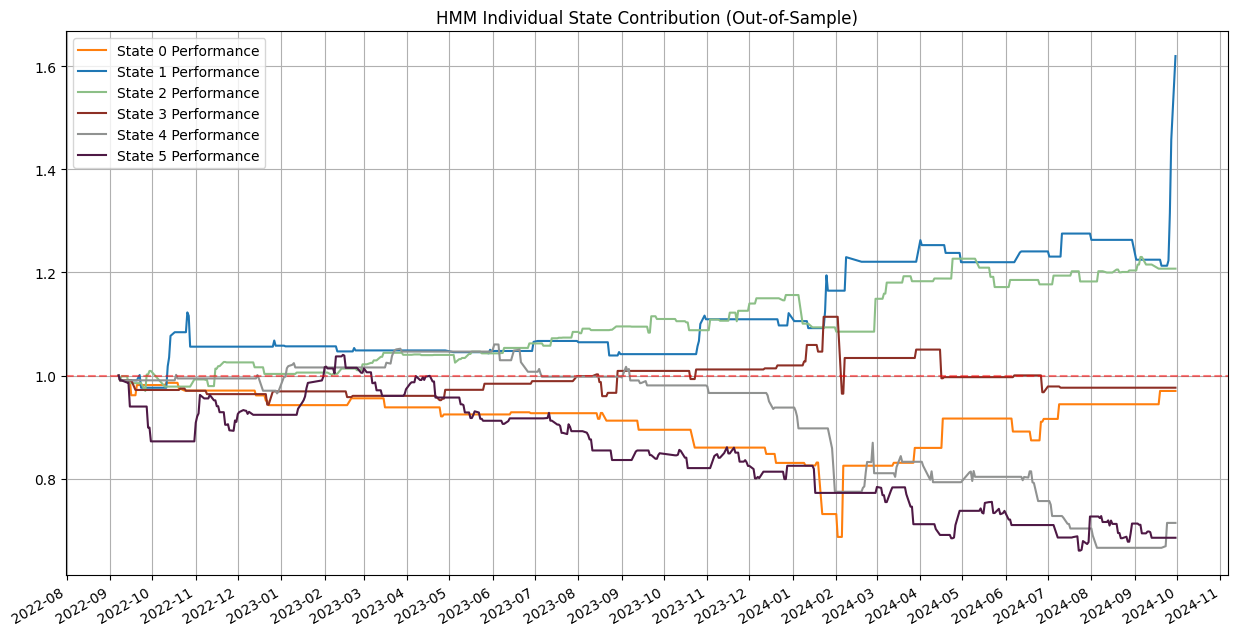

In [112]:

colors = ['#ff7f0e', '#1f77b4', "#8CBF87", "#8D2F25", "#909291", "#4E1945", "#B7B7Eb"]
plt.figure(figsize=(15, 8))
for i in range(model.n_components):
    df_train_sample = df_train_plot.copy()
    df_train_sample['signal'] = (df_train_plot['state'] == i).shift(1).fillna(0).astype(float)

    # 计算策略收益序列
    f3_vals = df_train_sample['f3'].astype(float).values
    signal = df_train_sample['signal'].astype(float).values
    strat_ret = f3_vals * signal
    # 强制第一行跟随市场，确保起跑线逻辑一致
    strat_ret[0] = f3_vals[0]
    
    # 净值为 1.0 的起点
    # 在所有收益率前面插一个 0
    strategy_cum = np.exp(np.insert(np.cumsum(strat_ret), 0, 0))
    # 插入数据后对应时间也要增加一列
    time_delta = df_train_sample.index[1] - df_train_sample.index[0] # 计算时间间隔
    plot_dates = [df_train_sample.index[0] - time_delta] + list(df_train_sample.index) #增加第一个时间
    plt.plot(plot_dates, strategy_cum, color=colors[i], label=f'State {i} Performance')

plt.axhline(1, color='red', linestyle='--', alpha=0.5) #基准线
plt.title("HMM Individual State Contribution (Out-of-Sample)")
plt.legend()
plt.grid(True)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate()
plt.show()

### 样本外状态分类

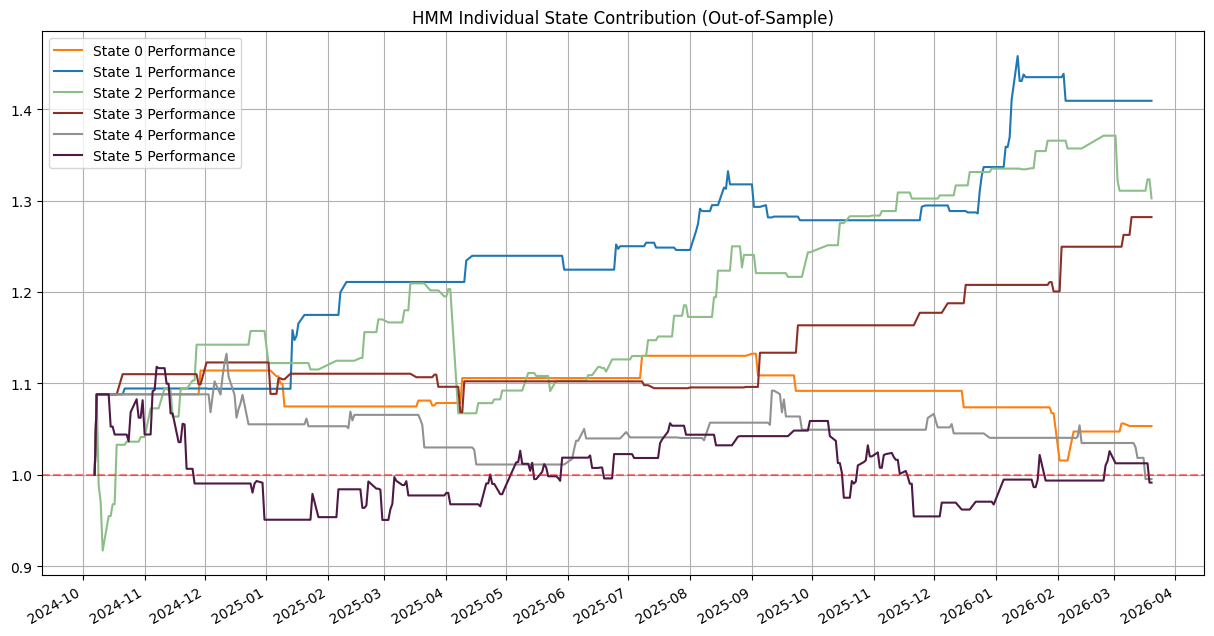

In [113]:
colors = ['#ff7f0e', '#1f77b4', "#8CBF87", "#8D2F25", "#909291", "#4E1945", "#B7B7Eb"]
plt.figure(figsize=(15, 8))
for i in range(model.n_components):
    df_test_sample = df_test_plot.copy()
    df_test_sample['signal'] = (df_test_plot['state'] == i).shift(1).fillna(0).astype(float)

    # 计算策略收益序列
    f3_vals = df_test_sample['f3'].astype(float).values
    signal = df_test_sample['signal'].astype(float).values
    strat_ret = f3_vals * signal
    # 强制第一行跟随市场，确保起跑线逻辑一致
    strat_ret[0] = f3_vals[0]
    
    # 净值为 1.0 的起点
    # 在所有收益率前面插一个 0
    strategy_cum = np.exp(np.insert(np.cumsum(strat_ret), 0, 0))
    # 插入数据后对应时间也要增加一列
    time_delta = df_test_sample.index[1] - df_test_sample.index[0] # 计算时间间隔
    plot_dates = [df_test_sample.index[0] - time_delta] + list(df_test_sample.index) #增加第一个时间
    plt.plot(plot_dates, strategy_cum, color=colors[i], label=f'State {i} Performance')

plt.axhline(1, color='red', linestyle='--', alpha=0.5) #基准线
plt.title("HMM Individual State Contribution (Out-of-Sample)")
plt.legend()
plt.grid(True)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate()
plt.show()

## 样本内样本外状态检验

In [114]:
state_train = df_train_plot.groupby('state')['f3'].mean().sort_values(ascending=False)
state_test = df_test_plot.groupby('state')['f3'].mean().sort_values(ascending=False)
print("state_train:",state_train)
print("state_test:",state_test)

state_train: state
1    0.025700
5    0.004739
4   -0.001246
3   -0.003758
2   -0.016415
0   -0.016548
Name: f3, dtype: float64
state_test: state
1    0.014725
5    0.007531
4    0.001192
0   -0.003794
3   -0.004088
2   -0.014028
Name: f3, dtype: float64


## 模型评估

In [115]:
# 计算最大回撤
def calculate_mdd(cum_series):
    """
    计算净值曲线的最大回撤及其结束时间点
    """
    # 转换为 numpy 数组方便计算
    nav = np.array(cum_series)
    # 计算历史滚动最高点
    peaks = np.maximum.accumulate(nav)
    # 计算回撤序列 (当前值 / 历史最高值 - 1)
    drawdowns = (nav - peaks) / peaks
    # 找到最大回撤值（最小值）
    mdd_value = np.min(drawdowns)
    # 找到最大回撤发生的索引位置（即回撤结束/最低点的位置）
    mdd_idx = np.argmin(drawdowns)
    
    return mdd_value, mdd_idx

【市场基准】最大回撤: -51.28% | 发生时间: 2024-02-05 00:00:00
【HMM策略】最大回撤: -16.19% | 发生时间: 2024-02-05 00:00:00


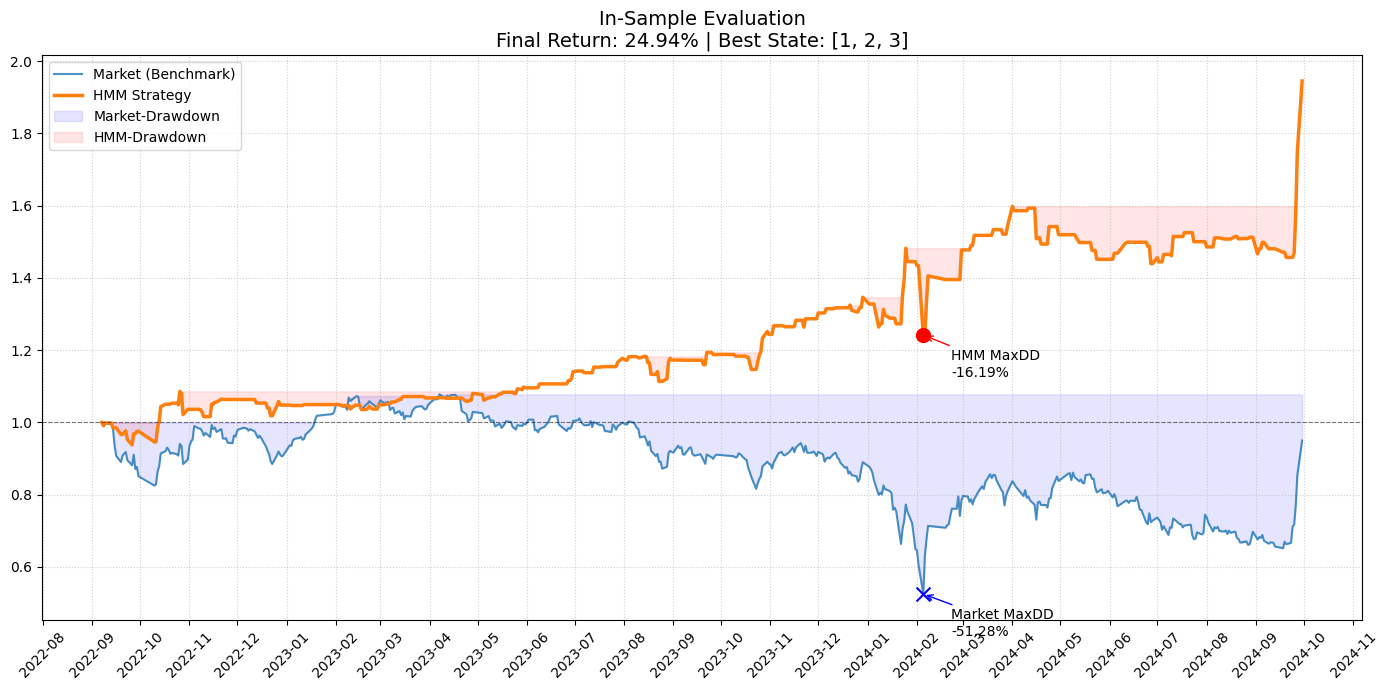

【市场基准】最大回撤: -18.65% | 发生时间: 2025-04-08 00:00:00
【HMM策略】最大回撤: -15.71% | 发生时间: 2024-10-11 00:00:00


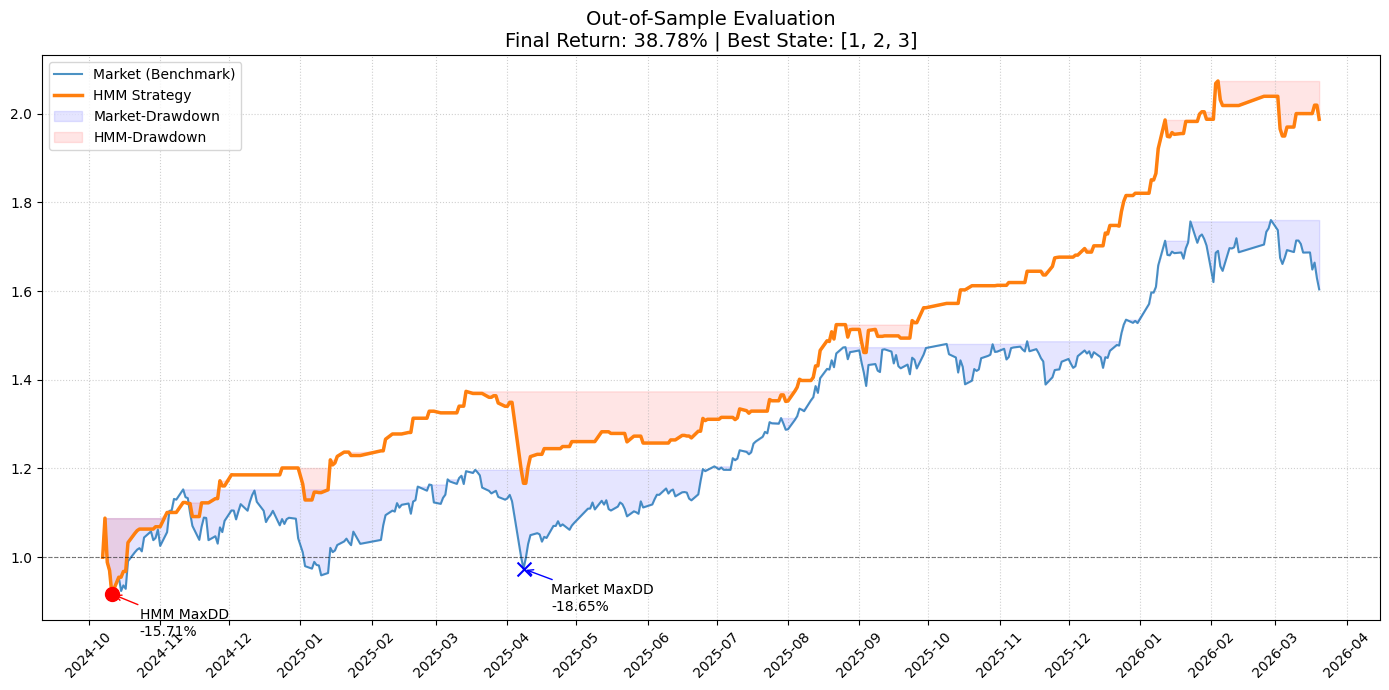

In [116]:
def plot_backtest(df_input, title, use_state):
    # 1. 深拷贝并预处理，确保无警告
    df = df_input.copy()
    df.index = pd.to_datetime(df.index)
    
    # T-1 时刻的状态决定 T 时刻的仓位
    # 这里后续可以考虑分不同权重
    signal = df['state'].isin(use_state).shift(1).fillna(0).astype(float) # state
    
    # 计算策略收益序列
    f3_vals = df['f3'].astype(float).values
    strat_ret = f3_vals * signal.values
    
    # 强制第一行跟随市场，确保起跑线逻辑一致
    strat_ret[0] = f3_vals[0]
    
    # 净值为 1.0 的起点
    # 在所有收益率前面插一个 0
    market_cum = np.exp(np.insert(np.cumsum(f3_vals), 0, 0))
    strategy_cum = np.exp(np.insert(np.cumsum(strat_ret), 0, 0))
    # 插入数据后对应时间也要增加一列
    time_delta = df.index[1] - df.index[0] # 计算时间间隔
    plot_dates = [df.index[0] - time_delta] + list(df.index) #增加第一个时间
    # 计算年化收益率 (Annualized Return)
    total_days = (df.index[-1] - df.index[0]).total_seconds() / (24 * 3600)# 持有天数 (分钟数据，直接用总时长)
    # 策略最终净值
    final_nav = strategy_cum[-1]
    # 年化公式: (最终净值 ^ (252 / 实际天数)) - 1
    annual_ret = ((final_nav ** (252 / total_days)) - 1) * 100

    m_mdd_val, m_mdd_idx = calculate_mdd(market_cum)
    s_mdd_val, s_mdd_idx = calculate_mdd(strategy_cum)

    # 获取对应的日期（从 plot_dates 中提取）
    m_mdd_date = plot_dates[m_mdd_idx]
    s_mdd_date = plot_dates[s_mdd_idx]

    print(f"【市场基准】最大回撤: {m_mdd_val:.2%} | 发生时间: {m_mdd_date}")
    print(f"【HMM策略】最大回撤: {s_mdd_val:.2%} | 发生时间: {s_mdd_date}")

    plt.figure(figsize=(14, 7), dpi=100)
    
    # 使用你指定的蓝色和橙色
    plt.plot(plot_dates, market_cum, color='#1f77b4', label='Market (Benchmark)', alpha=0.8)
    plt.plot(plot_dates, strategy_cum, color='#ff7f0e', label='HMM Strategy', linewidth=2.5)
    
    # 绘制最大回撤区域（可选，更专业）
    market_peak = np.maximum.accumulate(market_cum)
    strategy_peak = np.maximum.accumulate(strategy_cum)
    plt.fill_between(plot_dates, market_cum, market_peak, color='blue', alpha=0.1, label='Market-Drawdown')
    plt.fill_between(plot_dates, strategy_cum, strategy_peak, color='red', alpha=0.1, label='HMM-Drawdown')

    # 起始点辅助线
    plt.axhline(1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # 标题与统计信息
    plt.title(f"{title}\nFinal Return: {annual_ret:.2f}% | Best State: {use_state}", fontsize=14)
    
    # 坐标轴优化
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left')
    
    plt.tight_layout()
    plt.scatter(m_mdd_date, market_cum[m_mdd_idx], color='blue', s=100, marker='x', 
            label=f'Market MaxDD: {m_mdd_val:.2%}', zorder=5)

    # 标记策略最大回撤点
    plt.scatter(s_mdd_date, strategy_cum[s_mdd_idx], color='red', s=100, marker='o', 
                label=f'HMM MaxDD: {s_mdd_val:.2%}', zorder=5)
    plt.annotate(f'Market MaxDD\n{m_mdd_val:.2%}', 
                xy=(m_mdd_date, market_cum[m_mdd_idx]), 
                xytext=(20, -30), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='blue'))
    plt.annotate(f'HMM MaxDD\n{s_mdd_val:.2%}', 
                xy=(s_mdd_date, strategy_cum[s_mdd_idx]), 
                xytext=(20, -30), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='red'))
    plt.show()
# 状态总数
states = model.n_components
# 训练集确定best_state
# best_state = df_train_plot.groupby('state')['f3'].mean().idxmax()
buy_state = [1,2,3]
plot_backtest(df_train_plot, "In-Sample Evaluation", buy_state)
plot_backtest(df_test_plot, "Out-of-Sample Evaluation", buy_state)